# Install Dependencies

In [1]:
!pip install gymnasium==0.29.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 12.5 MB/s eta 0:00:0000:010:01
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.29.0
    Uninstalling gymnasium-0.29.0:
      Successfully uninstalled gymnasium-0.29.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.18.0 requires gymnasium==0.29.0, but you have gymnasium 0.29.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


# Libraries

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import random

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

# Seed for Reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Actor

In [5]:
class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dim=128):
        super().__init__()
        #Feed forward
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh()
        )
        #LSTM
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        #Feed Forward
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x, hidden):
        x = self.encoder(x)
        out, hidden = self.lstm(x, hidden)
        h = out[:, -1]
        probs = self.head(h)
        return probs, hidden

# Critic

In [6]:
class Critic(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        #Feed forward
        self.ff = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh()
        )
        #LSTM
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        #Feed Forward
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, hidden):
        x = self.ff(x)
        out, hidden = self.lstm(x, hidden)
        h = out[:, -1]
        value = self.out(h)
        return value.squeeze(-1), hidden

# Agent

In [7]:
class Agent:
    def __init__(self, input_dim, action_dim, gamma=0.99, actor_lr=1e-3, critic_lr=1e-3):
        self.actor = Actor(input_dim, action_dim).to(device)
        self.critic = Critic(input_dim).to(device)

        self.actor_optim = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.gamma = gamma
        self.reset_hidden()

    def reset_hidden(self):
        self.actor_hidden = None
        self.critic_hidden = None

    def choose_action(self, obs):
        #Observation to tensor
        obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)

        #Forward pass
        probs, self.actor_hidden = self.actor(obs, self.actor_hidden)
        value, self.critic_hidden = self.critic(obs, self.critic_hidden)

        #Detach hidden states
        self.actor_hidden = tuple(h.detach() for h in self.actor_hidden)
        self.critic_hidden = tuple(h.detach() for h in self.critic_hidden)

        #Sample action from categorical distribution
        dist = Categorical(probs)
        action = dist.sample()

        return action.item(), dist.log_prob(action), value

    def update(self, reward, log_prob, value, next_obs, done):
        #Observation to tensor
        next_obs = torch.tensor(next_obs, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)

        #Next value without gradients
        with torch.no_grad():
            next_value, _ = self.critic(next_obs, self.critic_hidden)

        #TD target and error
        td_target = reward + self.gamma * next_value * (1 - done)
        td_error = td_target - value

        #Losses
        actor_loss = -(log_prob * td_error.detach())
        critic_loss = td_error.pow(2)

        #Zero grad
        self.actor_optim.zero_grad()
        self.critic_optim.zero_grad()

        #Backpropagation
        (actor_loss + critic_loss).backward()

        #Optimizer step
        self.actor_optim.step()
        self.critic_optim.step()

    #Deterministic action selection for evaluation 
    def act(self, obs):
        #Observation to tensor
        obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        #Probability and hidden state
        probs, self.actor_hidden = self.actor(obs, self.actor_hidden)
        #Detach hidden state
        self.actor_hidden = tuple(h.detach() for h in self.actor_hidden)
        #Deterministic action via argmax
        action = torch.argmax(probs, dim=-1)
        return action.item()

## Environment and Agent Creation

In [8]:
env = gym.make("Blackjack-v1")
env.reset(seed=SEED)
env.action_space.seed(SEED)

obs_dim = 3
action_dim = env.action_space.n

agent = Agent(obs_dim, action_dim)

num_episodes = 5000
episode_rewards = []
average_episode_rewards = []

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Observation Processing

In [9]:
def process_observation(obs):
    player_sum, dealer_card, usable_ace = obs
    return np.array([player_sum / 32.0,dealer_card / 11.0,float(usable_ace)], dtype=np.float32)

# Training loop

In [10]:
for episode in range(num_episodes):
    obs, _ = env.reset()
    agent.reset_hidden()

    done = False
    total_reward = 0

    while not done:
        #State observation
        state = process_observation(obs)
        
        #Action selection
        action, log_prob, value = agent.choose_action(state)

        obs, reward, terminated, truncated, _ = env.step(action)
        #Termination condition
        done = terminated or truncated

        #Agent update
        next_state = process_observation(obs)
        agent.update(reward, log_prob, value, next_state, done)

        total_reward += reward

    episode_rewards.append(total_reward)
    if (episode + 1) % 500 == 0:
        avg = np.mean(episode_rewards[-500:])
        average_episode_rewards.append(avg)
        print(f"Episode {episode + 1}, Avg reward (last 500): {avg:.3f}")

env.close()

Episode 500, Avg reward (last 500): -0.158
Episode 1000, Avg reward (last 500): -0.194
Episode 1500, Avg reward (last 500): -0.194
Episode 2000, Avg reward (last 500): -0.298
Episode 2500, Avg reward (last 500): -0.164
Episode 3000, Avg reward (last 500): -0.200
Episode 3500, Avg reward (last 500): -0.156
Episode 4000, Avg reward (last 500): -0.156
Episode 4500, Avg reward (last 500): -0.146
Episode 5000, Avg reward (last 500): -0.130


# Learning Curve

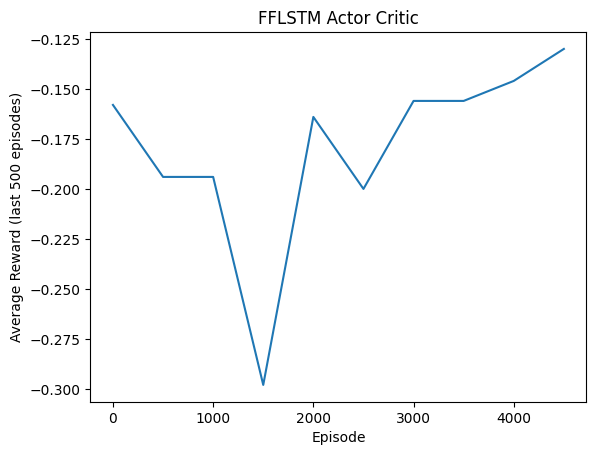

In [11]:
x = np.arange(len(average_episode_rewards)) * 500
plt.plot(x, average_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward (last 500 episodes)")
plt.title("FFLSTM Actor Critic")
plt.show()

# Evaluation

In [12]:
def evaluate_policy(env, agent, n_episodes=200):

    #Sets networks to evaluation mode
    agent.actor.eval()
    agent.critic.eval()
    eval_rewards = []
    #No gradient
    with torch.no_grad():
        for ep in range(n_episodes):
            obs, _ = env.reset()
            agent.reset_hidden()
            done = False
            total_reward = 0.0
            while not done:
                #State observation
                state = process_observation(obs)
                #Deterministic action
                action = agent.act(state)
                
                obs, reward, terminated, truncated, _ = env.step(action)
                #Termination condition
                done = terminated or truncated

                total_reward += reward

            eval_rewards.append(total_reward)

    eval_rewards = np.array(eval_rewards)
    mean_reward = eval_rewards.mean()
    std_reward = eval_rewards.std()
    return mean_reward, std_reward, eval_rewards

mean_eval, std_eval, eval_rewards = evaluate_policy(env=env,agent=agent,n_episodes=500)
print("Evaluation results (no exploration):")
print(f" Episodes        : {500}")
print(f" Mean reward     : {mean_eval:.3f}")
print(f" Std deviation   : {std_eval:.3f}")

Evaluation results (no exploration):
 Episodes        : 500
 Mean reward     : -0.176
 Std deviation   : 0.949
